Text(0, 0.5, 'Sensor 0 (raw)')

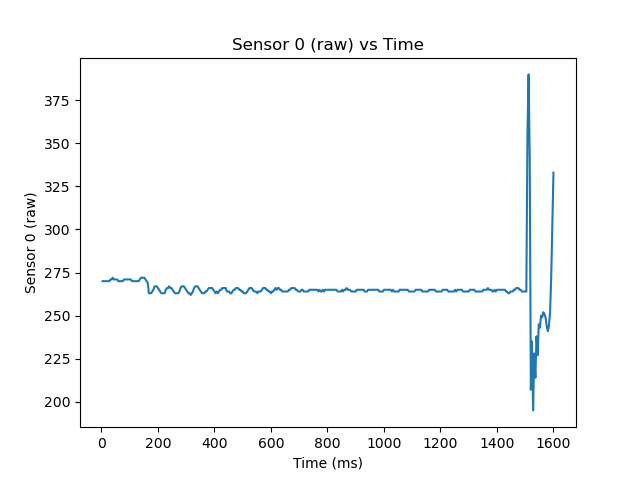

In [4]:
# As always, we start by importing our libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import sounddevice as sd

from scipy.signal import welch # We'll need this for power spectral density estimation 

# Allow for interactive plotting in Jupyter notebooks, comment out to turn this off. 
# The % sign is a Jupyter magic command that enables the use of widgets in the notebook.
# This requires installing the ipympl package.
%matplotlib widget 

# For interactive data point selection in plots, this library is useful.
import mplcursors


VCC = 5.01  # set to 3.3 if your board is 3.3V

# get unstrained data
data = pd.read_csv("/Users/caroline/Desktop/geng360-mahoney/frequency_soft.csv") 

plt.figure()  # Create a new figure
sns.lineplot(x="Time (ms)", y=data["Sensor 0 (raw)"], data=data)
plt.title("Sensor 0 (raw) vs Time")
plt.xlabel("Time (ms)")
plt.ylabel("Sensor 0 (raw)")

#mplcursors.cursor(hover=False)  # Enable interactive cursor for data point selection

# Click anywhere on your data to add a cursor
# Right-click to remove a cursor

#plt.show()

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
# from scipy.stats import linregress
import seaborn as sns
import sounddevice as sd

import mplcursors
from scipy.signal import welch # We'll need this for power spectral density estimation 

%matplotlib inline

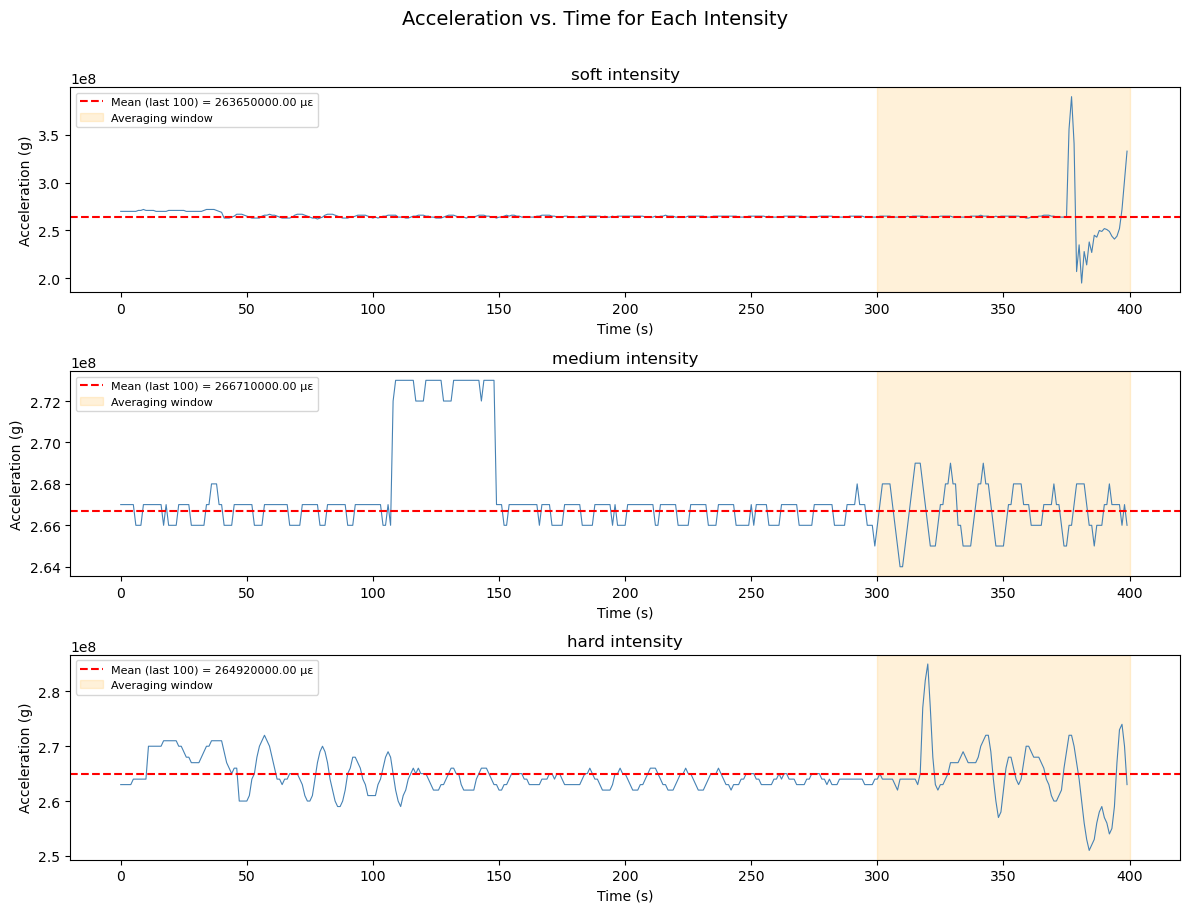

intensity  measured_frequency
     soft              263.65
   medium              266.71
     hard              264.92


'data = pd.read_csv("/Users/caroline/Desktop/geng360-mahoney/frequency_soft.csv")\n\n# Convert raw ADC → voltage → acceleration\n# AccelVolts = RawAccelData * (Vcc / 1023)\ndata["accel_volts"] = data["Sensor 0 (raw)"] * (VCC / 1023)\n\n# Convert voltage → g using ADXL335 sensitivity\n# From ADXL335 datasheet: sensitivity = 300 mV/g at 3.3V\n# But the board regulates 5V → 3.3V, so use 300 mV/g\nSENSITIVITY = 0.3    # V/g\nZERO_G_VOLTAGE = VCC / 2  # 0g output is roughly Vcc/2\n\ndata["accel_g"] = (data["accel_volts"] - ZERO_G_VOLTAGE) / SENSITIVITY\n\n# Plot raw acceleration vs time\nplt.figure(figsize=(12, 4))\nplt.plot(data["Time (ms)"] / 1000, data["accel_g"], color="steelblue", linewidth=0.8)\nplt.xlabel("Time (s)")\nplt.ylabel("Acceleration (g)")\nplt.title("Raw Accelerometer Data — Sensor 0 (Z axis)")\nplt.grid(True, alpha=0.3)\nplt.tight_layout()\nplt.show()'

In [16]:
VCC = 3.3  # set to 3.3 if your board is 3.3V
SAMPLE_RATE = 80  # Hz

results = []

DATA_DIR = "/Users/caroline/Desktop/geng360-mahoney/frequency_"

files = {
    "soft":   "soft.csv",
    "medium":  "medium.csv",
    "hard":  "hard.csv",
 }

intensity = ["soft", "medium", "hard"]

fig, axes = plt.subplots(len(intensity), 1, figsize=(12, 3 * len(intensity)), sharex=False)

for ax, intensity in zip(axes, intensity): # zip lets you loop through both axes and loads_g together
    # Load data — NO inversion
    df = pd.read_csv(DATA_DIR + files[intensity])

    # Use last 100 samples (most stable)
    mean_frequency = df["Sensor 0 (raw)"].tail(100).mean()

    results.append({
        "intensity":          intensity,
        "measured_frequency": mean_frequency,
    })

    # Plot
    ax.plot(df["Sensor 0 (raw)"] * 1e6, color="steelblue", linewidth=0.8)
    ax.axhline(mean_frequency * 1e6, color="red", linestyle="--", label=f"Mean (last 100) = {mean_frequency*1e6:.2f} µε") 
        # horizontal line along mean strain value
    ax.axvspan(len(df) - 100, len(df), alpha=0.15, color="orange", label="Averaging window") # highlights last 100 samples with a shaded area
    ax.set_title(f"{intensity} intensity")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Acceleration (g)")
    ax.legend(fontsize=8)

plt.suptitle("Acceleration vs. Time for Each Intensity", fontsize=14, y=1.01)
mplcursors.cursor(hover=False)
plt.tight_layout()
plt.show()

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False)) # converts DataFrame to string for printing
# index = False to hide the row numbers on the left side
"""data = pd.read_csv("/Users/caroline/Desktop/geng360-mahoney/frequency_soft.csv")

# Convert raw ADC → voltage → acceleration
# AccelVolts = RawAccelData * (Vcc / 1023)
data["accel_volts"] = data["Sensor 0 (raw)"] * (VCC / 1023)

# Convert voltage → g using ADXL335 sensitivity
# From ADXL335 datasheet: sensitivity = 300 mV/g at 3.3V
# But the board regulates 5V → 3.3V, so use 300 mV/g
SENSITIVITY = 0.3    # V/g
ZERO_G_VOLTAGE = VCC / 2  # 0g output is roughly Vcc/2

data["accel_g"] = (data["accel_volts"] - ZERO_G_VOLTAGE) / SENSITIVITY

# Plot raw acceleration vs time
plt.figure(figsize=(12, 4))
plt.plot(data["Time (ms)"] / 1000, data["accel_g"], color="steelblue", linewidth=0.8)
plt.xlabel("Time (s)")
plt.ylabel("Acceleration (g)")
plt.title("Raw Accelerometer Data — Sensor 0 (Z axis)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()"""

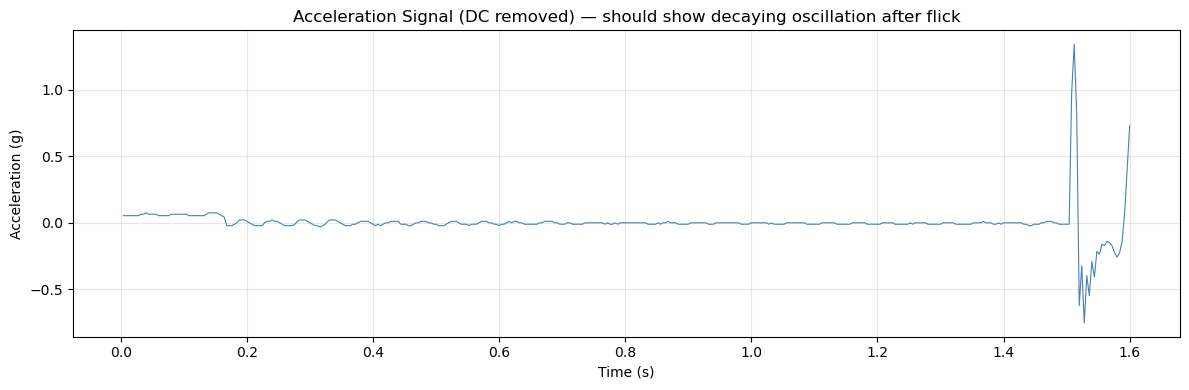

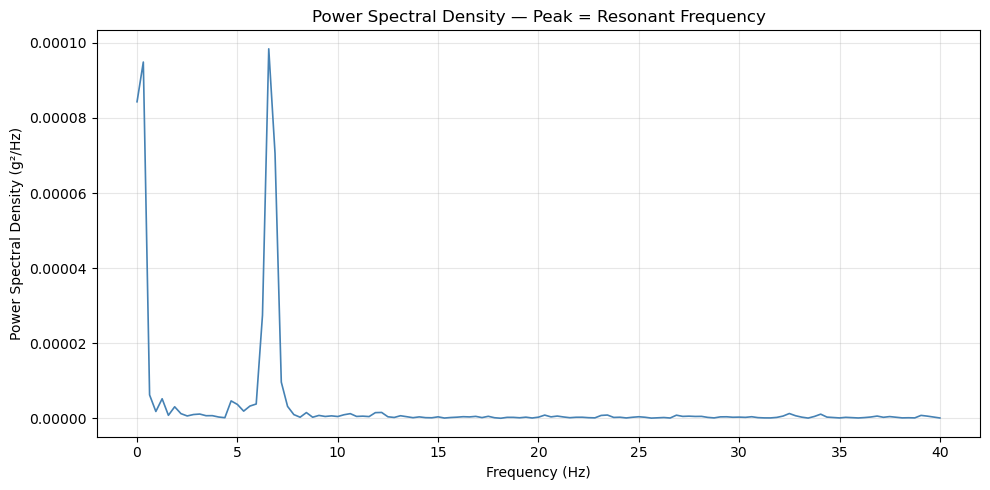

In [7]:
# Remove DC offset (gravity component) by subtracting the mean
# This isolates just the vibration signal
accel_signal = data["accel_g"] - data["accel_g"].mean()

# Plot DC-removed signal
plt.figure(figsize=(12, 4))
plt.plot(data["Time (ms)"] / 1000, accel_signal, color="steelblue", linewidth=0.8)
plt.xlabel("Time (s)")
plt.ylabel("Acceleration (g)")
plt.title("Acceleration Signal (DC removed) — should show decaying oscillation after flick")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Compute Power Spectral Density using Welch's method
# nperseg controls frequency resolution — larger = more resolution but needs more data
frequencies, psd = welch(accel_signal, fs=SAMPLE_RATE, nperseg=256)

# Plot PSD
plt.figure(figsize=(10, 5))
plt.plot(frequencies, psd, color="steelblue", linewidth=1.2)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (g²/Hz)")
plt.title("Power Spectral Density — Peak = Resonant Frequency")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Resonant frequency (experimental): 6.56 Hz
Peak PSD value: 0.000098 g²/Hz


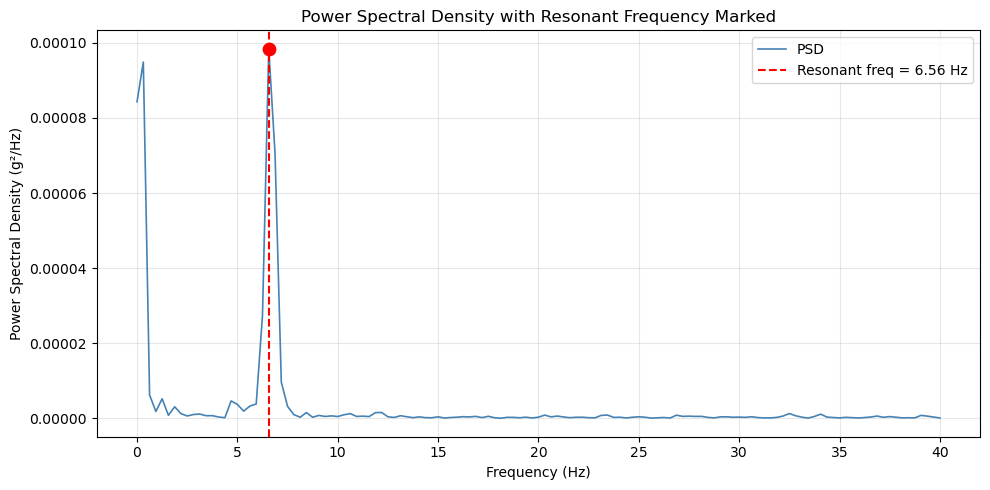

In [8]:
# Find the peak frequency (resonant frequency)
peak_idx = np.argmax(psd)
resonant_freq = frequencies[peak_idx]
peak_psd = psd[peak_idx]

print(f"Resonant frequency (experimental): {resonant_freq:.2f} Hz")
print(f"Peak PSD value: {peak_psd:.6f} g²/Hz")

# Plot PSD with peak marked
plt.figure(figsize=(10, 5))
plt.plot(frequencies, psd, color="steelblue", linewidth=1.2, label="PSD")
plt.axvline(resonant_freq, color="red", linestyle="--", linewidth=1.5,
            label=f"Resonant freq = {resonant_freq:.2f} Hz")
plt.scatter([resonant_freq], [peak_psd], color="red", zorder=5, s=80)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (g²/Hz)")
plt.title("Power Spectral Density with Resonant Frequency Marked")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# ── Beam properties (same as strain notebook) ────────────────────────────────
E_pa    = 10_000_000 * 6894.76      # Young's modulus in Pa
rho     = 0.09754 * 27679.9         # Density: lb/in³ → kg/m³
L       = 10.24 * 0.0254            # Length in meters
b       = 0.47  * 0.0254            # Width in meters
h       = 0.0984 * 0.0254           # Height in meters
I       = (b * h**3) / 12           # Second moment of area (m^4)
A       = b * h                     # Cross sectional area (m^2)
m_tip   = 1.6 / 1000                # Accelerometer tip mass in kg

# ── Theoretical resonant frequency (with tip mass correction) ────────────────
m_beam  = rho * A * L               # Total beam mass (kg)

# Standard cantilever formula with tip mass correction
# 0.2357 is the effective mass fraction (33/140) for first mode
fn_theory = (1 / (2 * np.pi)) * np.sqrt(
    3 * E_pa * I / ((0.2357 * m_beam + m_tip) * L**3)
)

print(f"Beam mass:                {m_beam*1000:.2f} g")
print(f"Tip mass (accelerometer): {m_tip*1000:.2f} g")
print(f"\nTheoretical resonant frequency (with tip mass): {fn_theory:.2f} Hz")
print(f"Experimental resonant frequency:                {resonant_freq:.2f} Hz")
print(f"Difference: {abs(fn_theory - resonant_freq):.2f} Hz ({abs(fn_theory - resonant_freq)/fn_theory*100:.1f}%)")

Beam mass:                20.95 g
Tip mass (accelerometer): 1.60 g

Theoretical resonant frequency (with tip mass): 26.60 Hz
Experimental resonant frequency:                6.56 Hz
Difference: 20.03 Hz (75.3%)
